### Weather and Air (Wind Speed) Prediction Time series
### PM25 Air Pollution Prediction
- Understand about air: https://www.deltrian.com/news/article/pm1
#### Project Team: 
- Rattanak SETH
- Makara Roeum

Dataset was taken from IOT device at Thailand. Burapha University in Thailand. Internship and Thesis Project for MAKARA. Data still in private, sorry cannot share now.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import statistics

### I. Data Preprocessing

In [2]:
df = pd.read_csv('data/pm_weatherdata.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
display(df)

,id_sensor,pm1,pm10,pm25,temperature,humidity,winddirection,direction,winddirection_volt,windspeed,windspeed_volt,Date,year,month
0,252,7,21,20,30.4,81,360,North,20.01,10,1.78,2024-02-15 18:07:40,2024,2
1,253,7,16,13,29.9,83,360,North,20.01,4,0.70,2024-02-15 18:37:37,2024,2
2,254,5,15,14,29.7,86,360,North,20.01,14,2.44,2024-02-15 19:07:37,2024,2
3,255,5,12,10,29.6,85,360,North,20.01,9,1.59,2024-02-15 19:37:37,2024,2
4,256,5,13,11,29.6,85,360,North,20.01,2,0.41,2024-02-15 20:07:37,2024,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,562,5,12,10,27.8,93,336,Northwest,19.07,0,0.00,2024-02-22 07:22:20,2024,2
311,563,110,130,130,32.6,73,360,North,20.01,5,0.91,2024-03-14 23:20:00,2024,3
312,564,2,8,5,29.7,82,360,North,20.01,4,0.72,2024-03-14 23:50:00,2024,3
313,565,2,8,6,29.5,83,360,North,20.01,0,0.07,2024-03-15 00:20:00,2024,3


### Statistical Analysis
This section will be focused on identifying key series of the dataset and provide statistical summary of the data. The central tendency of the data can be used to describe the data by identifying summary statistics such as mean,median and mode.

In [3]:
# Measures Mean(average) of per year ############################
for i in range(2023,2025):
    print(i)
    filtered_df = df.loc[(df['year'] == i)]
    if filtered_df.empty:
        print(f"No data available for the year {i}.")
        continue
    # Calculate the mean of windspeed for the filtered DataFrame
    WindSpeedMean = statistics.mean(filtered_df['windspeed'])
    TemperatureMean = statistics.mean(filtered_df['temperature'])
    HumidityMean = statistics.mean(filtered_df['humidity'])
    pm1Mean = statistics.mean(filtered_df['pm1'])
    pm10Mean = statistics.mean(filtered_df['pm10'])
    pm25Mean = statistics.mean(filtered_df['pm25'])
    
    data = {
            'year': [i] ,
            'Avergae Wind Speed': WindSpeedMean,
            'Avergae Temperature (C)': TemperatureMean,
            'Avergae Humidity': HumidityMean,
            'Avergae PM1': pm1Mean,
            'Avergae PM10': pm10Mean,
            'Avergae PM25': pm25Mean
            }
    newdf = pd.DataFrame(data)
    display(newdf)

2023
No data available for the year 2023.
2024


,year,Avergae Wind Speed,Avergae Temperature (C),Avergae Humidity,Avergae PM1,Avergae PM10,Avergae PM25
0,2024,0.355556,29.739683,79.504762,4.32381,10.346032,9.32381


In [4]:
# Measures Median of per year ############################
for i in range(2023,2025):
    print(i)
    filtered_df = df.loc[(df['year'] == i)]
    if filtered_df.empty:
        print(f"No data available for the year {i}.")
        continue
    
    # Calculate the mean of windspeed for the filtered DataFrame
    WindSpeedMedian = statistics.median(filtered_df['windspeed'])
    TemperatureMedian = statistics.median(filtered_df['temperature'])
    HumidityMedian = statistics.median(filtered_df['humidity'])
    pm1Median = statistics.median(filtered_df['pm1'])
    pm10Median = statistics.median(filtered_df['pm10'])
    pm25Median = statistics.median(filtered_df['pm25'])
    
    data = {
            'year': [i] ,
            'Median Wind Speed': WindSpeedMedian,
            'Median Temperature (C)': TemperatureMedian,
            'Median Humidity': HumidityMedian,
            'Median PM1': pm1Median,
            'Median PM10': pm10Median,
            'Median PM25': pm25Median
            }
    newdf = pd.DataFrame(data)
    display(newdf)

2023
No data available for the year 2023.
2024


,year,Median Wind Speed,Median Temperature (C),Median Humidity,Median PM1,Median PM10,Median PM25
0,2024,0,29.3,80,4,9,8


In [5]:
# Measures Mode of per year ############################
for i in range(2023,2025):
    print(i)
    filtered_df = df.loc[(df['year'] == i)]
    if filtered_df.empty:
        print(f"No data available for the year {i}.")
        continue
    
    # Calculate the mean of windspeed for the filtered DataFrame
    WindSpeedMode = statistics.mode(filtered_df['windspeed'])
    TemperatureMode = statistics.mode(filtered_df['temperature'])
    HumidityMode = statistics.mode(filtered_df['humidity'])
    pm1Mode = statistics.mode(filtered_df['pm1'])
    pm10Mode = statistics.mode(filtered_df['pm10'])
    pm25Mode = statistics.mode(filtered_df['pm25'])
    
    data = {
            'year': [i] ,
            'Mode Wind Speed': WindSpeedMode,
            'Mode Temperature (C)': TemperatureMode,
            'Mode Humidity': HumidityMode,
            'Mode PM1': pm1Mode,
            'Mode PM10': pm10Mode,
            'Mode PM25': pm25Mode
            }
    newdf = pd.DataFrame(data)
    display(newdf)

2023
No data available for the year 2023.
2024


,year,Mode Wind Speed,Mode Temperature (C),Mode Humidity,Mode PM1,Mode PM10,Mode PM25
0,2024,0,27.9,88,3,5,6


In [6]:
missing_value = ['N/a','na','nan',np.nan]
df1 = pd.read_csv('data/pm_weatherdata.csv', na_values=missing_value)
print(df1.isnull().sum())
# Drop any Nan values
df1 = df1.dropna()

display(df1)

id_sensor             0
pm1                   0
pm10                  0
pm25                  0
temperature           0
humidity              0
winddirection         0
direction             0
winddirection_volt    0
windspeed             0
windspeed_volt        0
Date                  0
dtype: int64


,id_sensor,pm1,pm10,pm25,temperature,humidity,winddirection,direction,winddirection_volt,windspeed,windspeed_volt,Date
0,252,7,21,20,30.4,81,360,North,20.01,10,1.78,2024-02-15 18:07:40
1,253,7,16,13,29.9,83,360,North,20.01,4,0.70,2024-02-15 18:37:37
2,254,5,15,14,29.7,86,360,North,20.01,14,2.44,2024-02-15 19:07:37
3,255,5,12,10,29.6,85,360,North,20.01,9,1.59,2024-02-15 19:37:37
4,256,5,13,11,29.6,85,360,North,20.01,2,0.41,2024-02-15 20:07:37
...,...,...,...,...,...,...,...,...,...,...,...,...
310,562,5,12,10,27.8,93,336,Northwest,19.07,0,0.00,2024-02-22 07:22:20
311,563,110,130,130,32.6,73,360,North,20.01,5,0.91,2024-03-14 23:20:00
312,564,2,8,5,29.7,82,360,North,20.01,4,0.72,2024-03-14 23:50:00
313,565,2,8,6,29.5,83,360,North,20.01,0,0.07,2024-03-15 00:20:00


In [7]:
df1.describe()

,id_sensor,pm1,pm10,pm25,temperature,humidity,winddirection,winddirection_volt,windspeed,windspeed_volt
count,315.000000,315.00000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000
mean,409.000000,4.32381,10.346032,9.323810,29.739683,79.504762,290.815873,17.230317,0.355556,0.063651
std,91.076891,7.03607,9.108560,8.996633,2.134919,8.479789,105.377836,4.254109,1.759576,0.310145
min,252.000000,0.00000,0.000000,0.000000,25.900000,55.000000,-78.000000,2.300000,0.000000,0.000000
25%,330.500000,2.00000,6.000000,6.000000,28.200000,75.000000,268.500000,16.335000,0.000000,0.000000
50%,409.000000,4.00000,9.000000,8.000000,29.300000,80.000000,335.000000,19.010000,0.000000,0.000000
75%,487.500000,5.00000,12.000000,11.000000,30.500000,86.000000,360.000000,20.010000,0.000000,0.000000
max,566.000000,110.00000,130.000000,130.000000,37.000000,94.000000,360.000000,20.010000,14.000000,2.440000


In [8]:
# Feature Engineering
df1['Date'] = pd.to_datetime(df1['Date'])
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month
df1['Day'] = df1['Date'].dt.day
df1['Hour'] = df1['Date'].dt.hour
df1['DayOfWeek'] = df1['Date'].dt.dayofweek
df1['DayOfYear'] = df1['Date'].dt.dayofyear
df1['WeekOfYear'] = df1['Date'].dt.isocalendar().week
df1['WeekOfYear'] = df1['WeekOfYear'].astype(int)
df1['IsWeekend'] = df1['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [9]:
# Map Direction name to their index in the list
# display(df1['direction'].unique())
direction_list = ['North', 'West', 'Unknown', 'Southwest', 'Northwest', 'South',
       'Northeast', 'East', 'Southeast']
df1['direction'] = df1['direction'].map(lambda x: direction_list.index(x) if x in direction_list else -1)

In [10]:
df1

,id_sensor,pm1,pm10,pm25,temperature,humidity,winddirection,direction,winddirection_volt,windspeed,windspeed_volt,Date,Year,Month,Day,Hour,DayOfWeek,DayOfYear,WeekOfYear,IsWeekend
0,252,7,21,20,30.4,81,360,0,20.01,10,1.78,2024-02-15 18:07:40,2024,2,15,18,3,46,7,0
1,253,7,16,13,29.9,83,360,0,20.01,4,0.70,2024-02-15 18:37:37,2024,2,15,18,3,46,7,0
2,254,5,15,14,29.7,86,360,0,20.01,14,2.44,2024-02-15 19:07:37,2024,2,15,19,3,46,7,0
3,255,5,12,10,29.6,85,360,0,20.01,9,1.59,2024-02-15 19:37:37,2024,2,15,19,3,46,7,0
4,256,5,13,11,29.6,85,360,0,20.01,2,0.41,2024-02-15 20:07:37,2024,2,15,20,3,46,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,562,5,12,10,27.8,93,336,4,19.07,0,0.00,2024-02-22 07:22:20,2024,2,22,7,3,53,8,0
311,563,110,130,130,32.6,73,360,0,20.01,5,0.91,2024-03-14 23:20:00,2024,3,14,23,3,74,11,0
312,564,2,8,5,29.7,82,360,0,20.01,4,0.72,2024-03-14 23:50:00,2024,3,14,23,3,74,11,0
313,565,2,8,6,29.5,83,360,0,20.01,0,0.07,2024-03-15 00:20:00,2024,3,15,0,4,75,11,0


In [11]:
print(list(df1.columns))

['id_sensor', 'pm1', 'pm10', 'pm25', 'temperature', 'humidity', 'winddirection', 'direction', 'winddirection_volt', 'windspeed', 'windspeed_volt', 'Date', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'IsWeekend']


In [12]:
# for example, we want to predict the windspeed based on the other features
features = ['Year', 'Month', 'Day', 'Hour', 'pm1', 'pm10', 'pm25', 'temperature', 'humidity', 'winddirection', 'direction', 'winddirection_volt']
target = 'windspeed'

X = df1[features]
y = df1[target]
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train the model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')

Mean Squared Error: 2.301542857142857
R2 Score: 0.3576073417721518


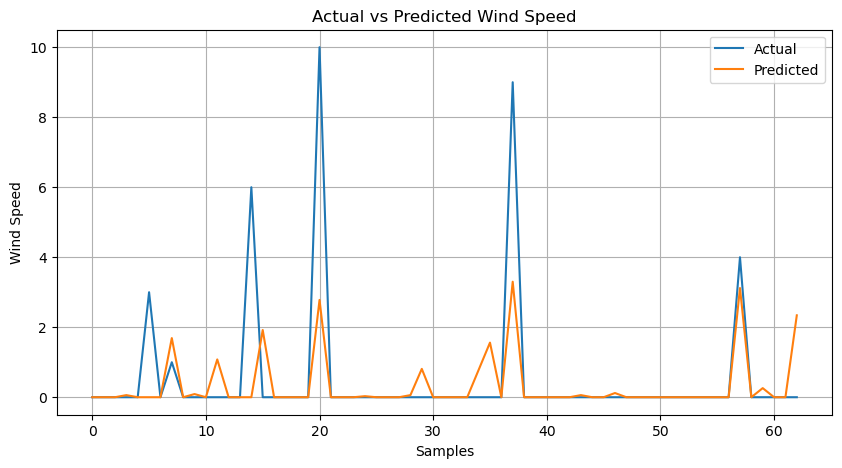

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Wind Speed')
plt.xlabel('Samples')
plt.ylabel('Wind Speed')
plt.grid()
plt.show()

### ARIMA

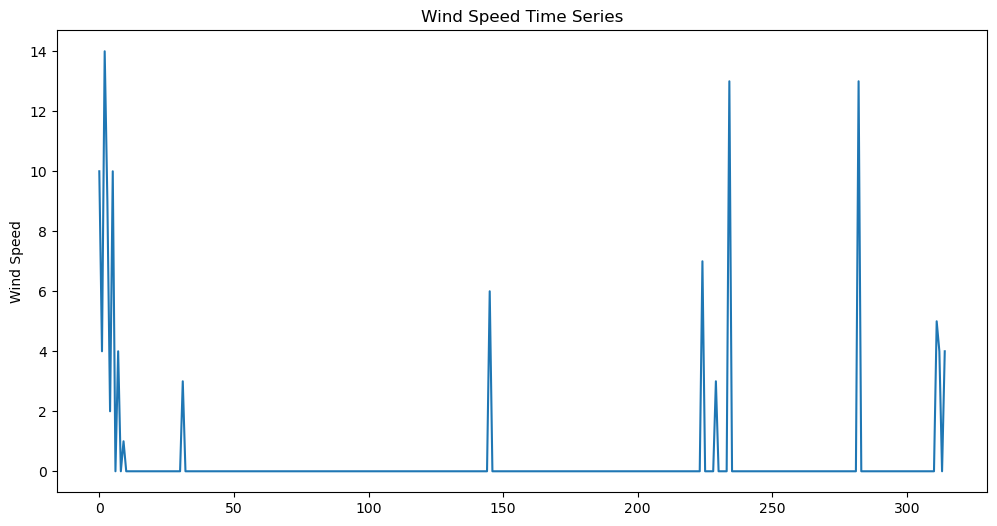

ADF Statistic: -14.253898974554682
p-value: 1.465138149135541e-26
                               SARIMAX Results                                
Dep. Variable:              windspeed   No. Observations:                  315
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -588.609
Date:                Mon, 12 May 2025   AIC                           1183.218
Time:                        21:40:07   BIC                           1194.466
Sample:                             0   HQIC                          1187.712
                                - 315                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1877      0.040     -4.744      0.000      -0.265      -0.110
ma.L1         -0.6575      0.030    -22.050      0.000      -0.71

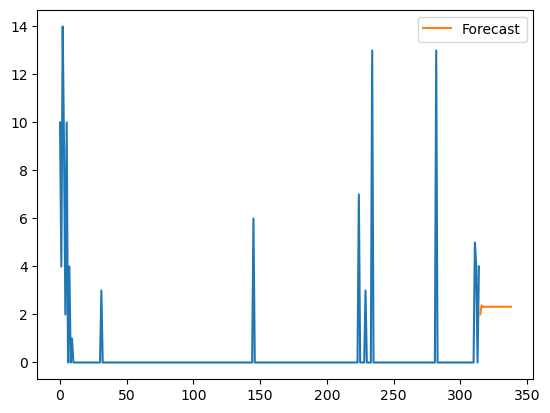

In [14]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Keep only the targe variable
ts = df1[target].astype('float')
# Visualize the time series
ts.plot(title='Wind Speed Time Series', figsize=(12, 6))
plt.ylabel('Wind Speed')
plt.show()

# Check stationarity (ADF test)
result = adfuller(ts.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p-value > 0.05 → non-stationary; differencing might be needed

# difference the time series if needed
ts_diff = ts.diff().dropna()

# (p, d, q) values can be determined using ACF and PACF or auto_arima
model = ARIMA(ts, order=(1,1,1))  # adjust order based on model diagnostics
model_fit = model.fit()

print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=24)  # predict next 30 minutes * 24
print(forecast)

# Plot forecast
ts.plot(label='Observed')
forecast.plot(label='Forecast', legend=True)
plt.show()
# model = ARIMA(X, order=(5, 1, 0))
# model_fit = model.fit()

# Make predictions
# predictions = model_fit.forecast(start=len(X), end=len(X)+len(X_test)-1)
# # Evaluate the model
# mse = mean_squared_error(y_test, predictions)
# r2 = r2_score(y_test, predictions)
# print(f'Mean Squared Error: {mse}')
# print(f'R2 Score: {r2}')
# plt.figure(figsize=(10, 5))
# plt.plot(y_test.values[:100], label='Actual')
# plt.plot(predictions[:100], label='Predicted')
# plt.legend()
# plt.title('Actual vs Predicted Wind Speed')
# plt.xlabel('Samples')
# plt.ylabel('Wind Speed')
# plt.grid()
# plt.show()

# # Forecast future values
# forecast = model_fit.forecast(steps=30)
# print(f'Forecasted values: {forecast}')

In [15]:
print(pd.to_datetime(df1[['Year', 'Month', 'Day', 'Hour']]))

0     2024-02-15 18:00:00
1     2024-02-15 18:00:00
2     2024-02-15 19:00:00
3     2024-02-15 19:00:00
4     2024-02-15 20:00:00
              ...        
310   2024-02-22 07:00:00
311   2024-03-14 23:00:00
312   2024-03-14 23:00:00
313   2024-03-15 00:00:00
314   2024-03-15 00:00:00
Length: 315, dtype: datetime64[ns]


### ARIMAX Model

In [16]:
import pandas as pd

# Define target and exogenous variables
y = df1['windspeed'].astype(float)
exog_vars = ['pm1', 'pm10', 'pm25', 'temperature', 'humidity', 'winddirection', 'direction', 'winddirection_volt']
X = df1[exog_vars].astype(float)

In [17]:
# Fit ARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit ARIMAX model; adjust (p,d,q) as needed
model = SARIMAX(y, exog=X, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              windspeed   No. Observations:                  315
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -584.726
Date:                Mon, 12 May 2025   AIC                           1191.453
Time:                        21:40:08   BIC                           1232.696
Sample:                             0   HQIC                          1207.933
                                - 315                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
pm1                    0.0360      0.056      0.644      0.519      -0.073       0.145
pm10                   0.0522      0.111      0.469      0.639      -0.166       0.270
pm25                

/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: title={'center': 'Forecasted Windspeed'}>

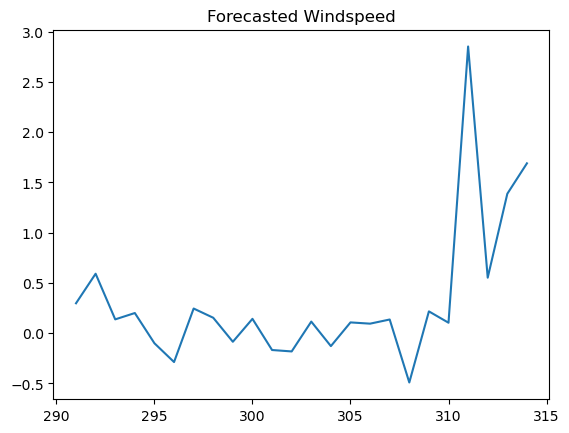

In [18]:
### Step 4: Forecasting with exogenous variables
"""To forecast into the future, you need future values of the exogenous variables.
If you only forecast within your known data:"""
forecast = model_fit.predict(start=len(y)-24, end=len(y)-1, exog=X[-24:])
forecast.plot(title='Forecasted Windspeed')


### Air pollution prediction
Predict with pm2.5 in air
- PM2.5 (ug/m3), 2.5 Particulate Matter concentration
- A measure of concentration in terms of mass per unit volume. A concentration of 1 µg/m3 means that one cubic metre of air contains one microgram (10-6 grams) of pollutant.
Model: Logistic Regression, GRU, LSTM and other Fine-Tuning the Model

In [19]:
features = ['Year', 'Month', 'Day', 'Hour', 'temperature', 'humidity', 'winddirection', 'direction', 'winddirection_volt', 'windspeed']
# targets = ['pm1', 'pm10', 'pm25']
target = 'pm25'
X = df1[features]
y = df1[target]
X

,Year,Month,Day,Hour,temperature,humidity,winddirection,direction,winddirection_volt,windspeed
0,2024,2,15,18,30.4,81,360,0,20.01,10
1,2024,2,15,18,29.9,83,360,0,20.01,4
2,2024,2,15,19,29.7,86,360,0,20.01,14
3,2024,2,15,19,29.6,85,360,0,20.01,9
4,2024,2,15,20,29.6,85,360,0,20.01,2
...,...,...,...,...,...,...,...,...,...,...
310,2024,2,22,7,27.8,93,336,4,19.07,0
311,2024,3,14,23,32.6,73,360,0,20.01,5
312,2024,3,14,23,29.7,82,360,0,20.01,4
313,2024,3,15,0,29.5,83,360,0,20.01,0


### Logistic Regression
We cannot use Logistic Regression to predict timeseries data

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

without scaling
Mean Squared Error: 100.66666666666667
R2 Score: -0.0817720065846479


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


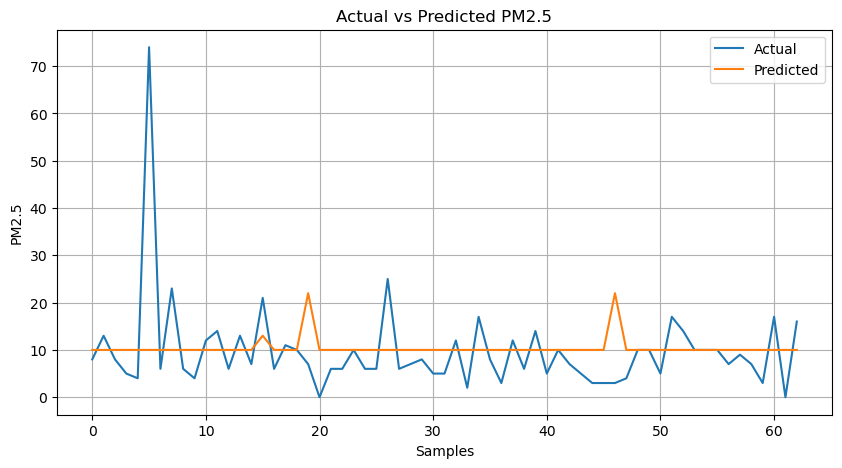

with scaling
Mean Squared Error: 85.80952380952381
R2 Score: 0.07788403223011575


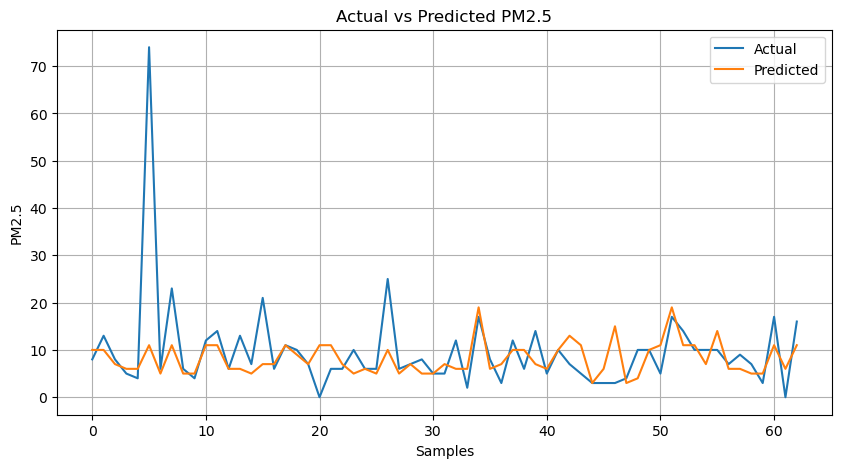

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train the model
logisticRegressionModel = LogisticRegression()
logisticRegressionModel.fit(X_train, y_train)
y_pred = model.predict(X_test)

def mse_plot(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Mean Squared Error: {mse}')
    print(f'R2 Score: {r2}')
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.values[:100], label='Actual')
    plt.plot(y_pred[:100], label='Predicted')
    plt.legend()
    plt.title('Actual vs Predicted PM2.5')
    plt.xlabel('Samples')
    plt.ylabel('PM2.5')
    plt.grid()
    plt.show()

# without scaling
print("without scaling")
mse_plot(y_test, y_pred)

# with scaling
print("with scaling")
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)
logisticRegressionModelScaler = LogisticRegression()
logisticRegressionModelScaler.fit(X_train_scaler, y_train)
y_pred_scaler = logisticRegressionModelScaler.predict(X_test_scaler)
mse_plot(y_test, y_pred_scaler)

### Linear Regression (Time series)

Without scaling
Mean Squared Error: 149.54
R2 Score: -6.58


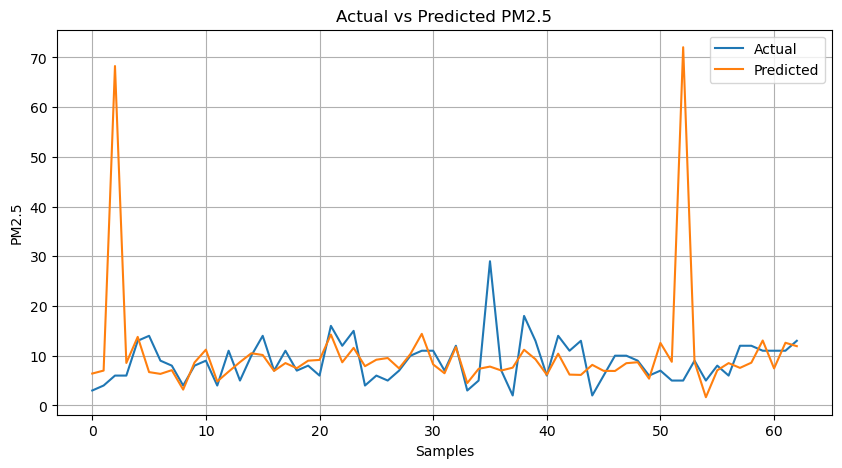

With scaling
Mean Squared Error: 149.54
R2 Score: -6.58


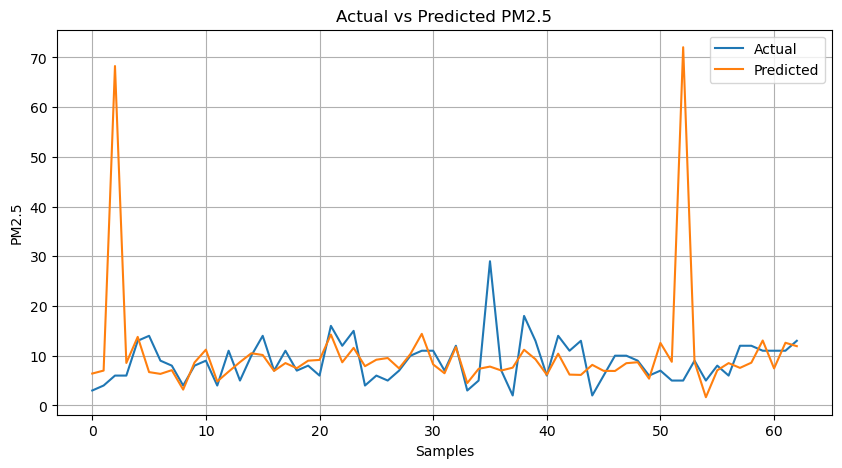

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train the model (without scaling)
print("Without scaling")
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation + Plot
def mse_plot(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R2 Score: {r2:.2f}')
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.values[:100], label='Actual')
    plt.plot(y_pred[:100], label='Predicted')
    plt.legend()
    plt.title('Actual vs Predicted PM2.5')
    plt.xlabel('Samples')
    plt.ylabel('PM2.5')
    plt.grid()
    plt.show()

mse_plot(y_test, y_pred)

# With scaling
print("With scaling")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
mse_plot(y_test, y_pred_scaled)


Mean Squared Error: 254.63
R2 Score: -0.05


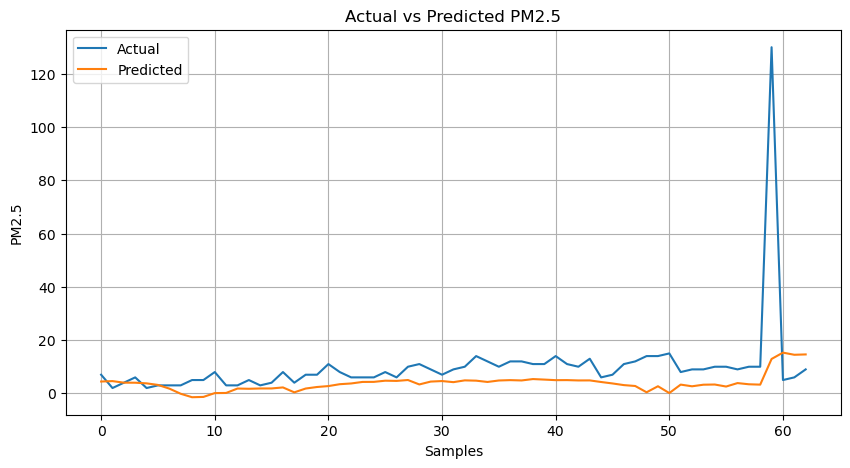

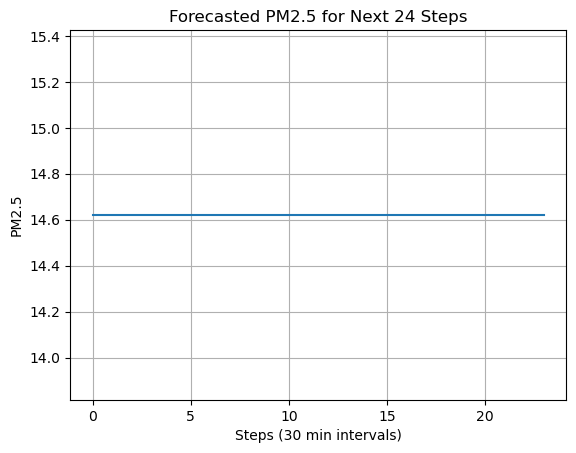

In [31]:
"""
Forecasting Next PM2.5
"""
# Use last portion of data as test
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

model = LinearRegression()
model.fit(X_train, y_train)

# Predict future
y_pred = model.predict(X_test)
mse_plot(y_test, y_pred)

# Assume last row repeats for next steps (just for demonstration)
future_X = pd.DataFrame([X.iloc[-1].values] * 24, columns=X.columns)
future_y_pred = model.predict(future_X)

# Plot (one step equals a half hour)
plt.plot(future_y_pred)
plt.title('Forecasted PM2.5 for Next 24 Steps')
plt.xlabel('Steps (30 min intervals)')
plt.ylabel('PM2.5')
plt.grid()
plt.show()


### Time Series Forecasting with GRU

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense


2025-05-12 22:38:50.878289: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Prepare the data
# df['pm25'] is the target
target_col = 'pm25'
data = df[[target_col]].astype(float)

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 24  # use last 24 steps to predict the next (24 * 30 min = 12 hours)
X, y = create_sequences(data_scaled, lookback=lookback)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0018 - val_loss: 3.7524e-04
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0012 - val_loss: 2.6220e-04
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0011 - val_loss: 7.7444e-04
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0011 - val_loss: 5.5060e-04
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0011 - val_loss: 3.2016e-04
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0012 - val_loss: 4.6443e-04
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 9.3604e-04 - val_loss: 4.9262e-04
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 8.7984e-04 - val_loss: 3.6865e-04
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0011 - val_loss: 4.1438e-04
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0011 - val_loss: 4.2323e-04
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 

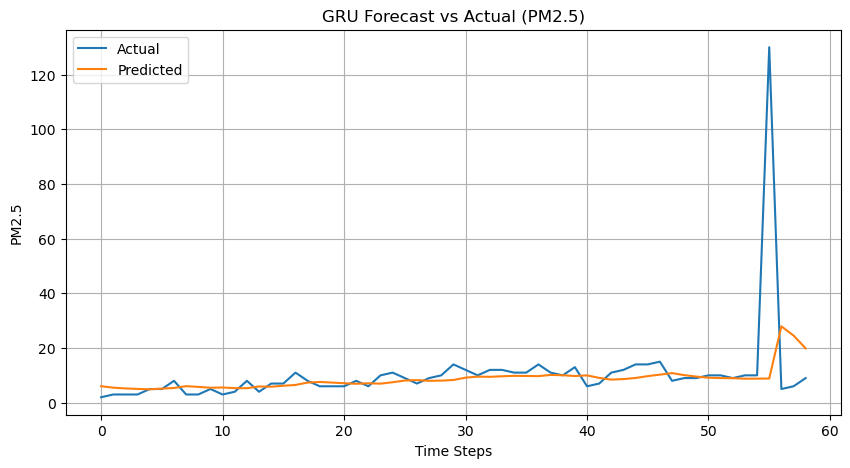

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


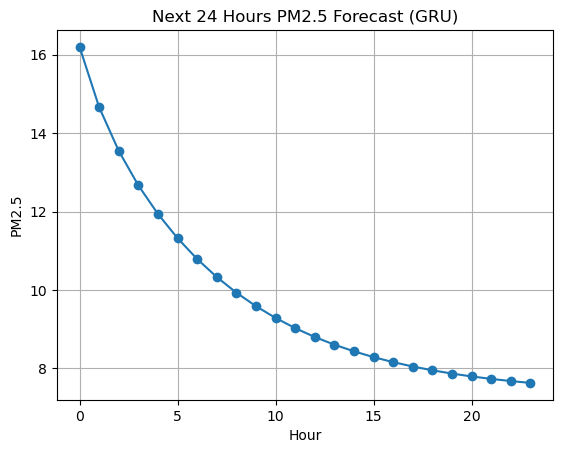

In [35]:
# Train test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build GRU model
model = Sequential()
model.add(GRU(64, activation='tanh', return_sequences=False, input_shape=(lookback, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.summary()

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)
y_pred = model.predict(X_test)

# Inverse scale
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test_inv[:100], label='Actual')
plt.plot(y_pred_inv[:100], label='Predicted')
plt.legend()
plt.title('GRU Forecast vs Actual (PM2.5)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.grid()
plt.show()

# Start from last available window
last_sequence = data_scaled[-lookback:]
future_steps = 24
future_preds = []

input_seq = last_sequence.copy()

for _ in range(future_steps):
    pred = model.predict(input_seq.reshape(1, lookback, 1))
    future_preds.append(pred[0, 0])
    input_seq = np.append(input_seq[1:], pred, axis=0)

# Inverse scale
future_preds_inv = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

# Plot
plt.plot(future_preds_inv, marker='o')
plt.title('Next 24 Hours PM2.5 Forecast (GRU)')
plt.xlabel('Hour')
plt.ylabel('PM2.5')
plt.grid()
plt.show()

